# Run the whole notebook to get animation on how k means clustering works

In [103]:
import matplotlib.pyplot as plt

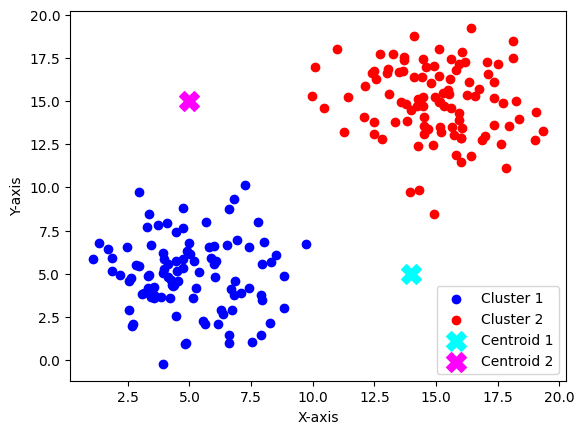

In [104]:
# create a point plot with points with clearly two different clusters random points, not in a straight line but 
# in a way that they are clearly two different clusters random here and there
import numpy as np
# Cluster 1
x1 = np.random.normal(5, 2, 100)
y1 = np.random.normal(5, 2, 100)
# Cluster 2
x2 = np.random.normal(15, 2, 100)
y2 = np.random.normal(15, 2, 100)
plt.scatter(x1, y1, color='blue', label='Cluster 1')
plt.scatter(x2, y2, color='red', label='Cluster 2')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')


# now plot on top of it the first random centroid points
centroid1_x = 14
centroid1_y = 5
centroid2_x = 5
centroid2_y = 15
plt.scatter(centroid1_x, centroid1_y, color='cyan', label='Centroid 1', marker='X', s=200)
plt.scatter(centroid2_x, centroid2_y, color='magenta', label='Centroid 2', marker='X', s=200)
plt.legend()

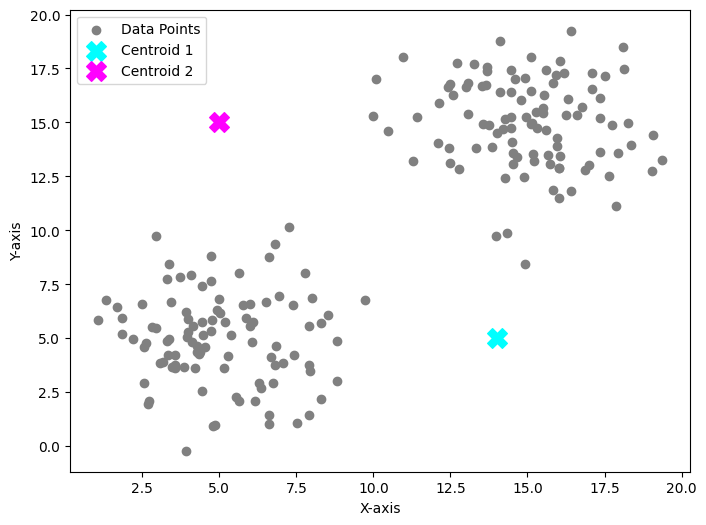

In [105]:
# What the algorithm sees

# combine x1 x2 and y1 y2 into a single dataset
X = np.concatenate((np.column_stack((x1, y1)), np.column_stack((x2, y2))), axis=0)
# Plot the combined dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='gray', label='Data Points')
plt.scatter(centroid1_x, centroid1_y, color='cyan', label='Centroid 1', marker='X', s=200)
plt.scatter(centroid2_x, centroid2_y, color='magenta', label='Centroid 2', marker='X', s=200)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()

In [106]:
def calculate_distance(point, centroid):
    return np.sqrt((point[0] - centroid[0]) ** 2 + (point[1] - centroid[1]) ** 2)

In [107]:
# # step 1: Assign points to the nearest centroid
# centroid1_x_points = []
# centroid1_y_points = []
# centroid2_x_points = []
# centroid2_y_points = []
# for i in X:
#     distance_to_centroid1 = calculate_distance(i, (centroid1_x, centroid1_y))
#     distance_to_centroid2 = calculate_distance(i, (centroid2_x, centroid2_y))
#     if distance_to_centroid1 < distance_to_centroid2:
#         centroid1_x_points.append(i[0])
#         centroid1_y_points.append(i[1])
#     else:
#         centroid2_x_points.append(i[0])
#         centroid2_y_points.append(i[1])

# # color the points based on which centroid they are closer to
# plt.figure(figsize=(8, 6))
# plt.scatter(centroid1_x_points, centroid1_y_points, color='blue', label='Points closer to Centroid 1')
# plt.scatter(centroid2_x_points, centroid2_y_points, color='red', label='Points closer to Centroid 2')
# plt.scatter(centroid1_x, centroid1_y, color='cyan', label='Centroid 1', marker='X', s=200)
# plt.scatter(centroid2_x, centroid2_y, color='magenta', label='Centroid 2', marker='X', s=200)
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.legend()


# # calculate mean of points for centroid 1 and centroid 2
# new_centroid1_x = centroid1_x + (np.mean(centroid1_x_points) - centroid1_x) / 3
# new_centroid1_y = centroid1_y + (np.mean(centroid1_y_points) - centroid1_y) / 3
# new_centroid2_x = centroid2_x + (np.mean(centroid2_x_points) - centroid2_x) / 3
# new_centroid2_y = centroid2_y + (np.mean(centroid2_y_points) - centroid2_y) / 3
# # assign new centroids to old centroids
# centroid1_x = new_centroid1_x
# centroid1_y = new_centroid1_y
# centroid2_x = new_centroid2_x
# centroid2_y = new_centroid2_y

MovieWriter imagemagick unavailable; using Pillow instead.


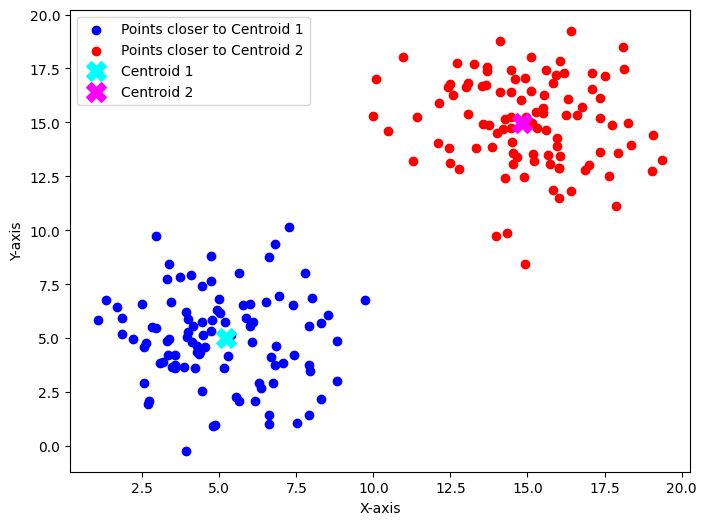

In [108]:
# create the last cell code as maatplotlin animation to show the movement of centroids and points changing color based on which centroid they are closer to
import matplotlib.animation as animation
fig, ax = plt.subplots(figsize=(8, 6))
def update(frame):
    global centroid1_x, centroid1_y, centroid2_x, centroid2_y
    # step 1: Assign points to the nearest centroid
    centroid1_x_points = []
    centroid1_y_points = []
    centroid2_x_points = []
    centroid2_y_points = []
    for i in X:
        distance_to_centroid1 = calculate_distance(i, (centroid1_x, centroid1_y))
        distance_to_centroid2 = calculate_distance(i, (centroid2_x, centroid2_y))
        if distance_to_centroid1 < distance_to_centroid2:
            centroid1_x_points.append(i[0])
            centroid1_y_points.append(i[1])
        else:
            centroid2_x_points.append(i[0])
            centroid2_y_points.append(i[1])
    ax.clear()
    ax.scatter(centroid1_x_points, centroid1_y_points, color='blue', label='Points closer to Centroid 1')
    ax.scatter(centroid2_x_points, centroid2_y_points, color='red', label='Points closer to Centroid 2')
    ax.scatter(centroid1_x, centroid1_y, color='cyan', label='Centroid 1', marker='X', s=200)
    ax.scatter(centroid2_x, centroid2_y, color='magenta', label='Centroid 2', marker='X', s=200)
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.legend()
    # calculate mean of points for centroid 1 and centroid 2
    new_centroid1_x = centroid1_x + (np.mean(centroid1_x_points) - centroid1_x) / 3
    new_centroid1_y = centroid1_y + (np.mean(centroid1_y_points) - centroid1_y) / 3
    new_centroid2_x = centroid2_x + (np.mean(centroid2_x_points) - centroid2_x) / 3
    new_centroid2_y = centroid2_y + (np.mean(centroid2_y_points) - centroid2_y) / 3
    # assign new centroids to old centroids
    centroid1_x = new_centroid1_x
    centroid1_y = new_centroid1_y
    centroid2_x = new_centroid2_x
    centroid2_y = new_centroid2_y
ani = animation.FuncAnimation(fig, update, frames=10, repeat=False)
# save it but needs to add delay between updates to show slowly
ani.save('kmeans_clustering.gif', writer='imagemagick', fps=1)

In [109]:
# 